In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import json

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# loading the final training dataset for EDA
train_df = pd.read_parquet('../data/raw/train_df.parquet', engine="fastparquet")

In [3]:
corr = train_df.corr(numeric_only=True)['target'].abs().sort_values(ascending=False)
corr.head(9)

target                    1.000000
pct_PL_enq_L6m_of_ever    0.384625
pct_tl_open_L6M           0.207604
num_std_12mts             0.171823
pct_CC_enq_L6m_of_ever    0.166339
enq_L3m                   0.148043
PL_enq_L12m               0.148029
CC_enq_L12m               0.148020
time_since_recent_enq     0.144992
Name: target, dtype: float64

In [4]:
top6_features = ['pct_PL_enq_L6m_of_ever', 'pct_tl_open_L6M', 'num_std_12mts',
                  'pct_CC_enq_L6m_of_ever', 'enq_L3m', 'PL_enq_L12m', 'CC_enq_L12m',
                  'time_since_recent_enq'
                ]

temp_corr = train_df.corr(numeric_only=True)['target']
for feature in top6_features:
    print(f"{feature} = {temp_corr[feature]}")

pct_PL_enq_L6m_of_ever = -0.38462508833457865
pct_tl_open_L6M = -0.20760377995684182
num_std_12mts = 0.1718229056063518
pct_CC_enq_L6m_of_ever = -0.1663385619784543
enq_L3m = -0.14804252593058773
PL_enq_L12m = -0.148029024898981
CC_enq_L12m = -0.14802005029508508
time_since_recent_enq = -0.14499200022184258


Above are the columns with high correlation with approval/target column
1. `pct_PL_enq_L6m_of_ever` means ***number of recent personal loan enquiries***, so the higher the number of enquiries the more riskier the borrower is.

2. `pct_tl_open_L6M` means ***number of new accounts opened recently***, so the higher the number of new accounts opened the risikier is the borrower.

3. `num_std_12mts` means ***number of standard/healthy payments in the last 12 months***, so the higher the number of healthy payments the less risky the borrower is.

4. `pct_CC_enq_L6m_of_ever` means ***number of recent credit card enquiries***, so the higher the number of enquiry the more riskier the borrower is.

5. `enq_L3m` means ***number of enquiries in last 3 months***, so the higher the number of enquiry the more riskier the borrower is.

6. `PL_enq_L12m` means ***number of personal loan enquiries in the last 12 months***, so the higher the number of enquiry the more riskier the borrower is.

7. `CC_enq_L12m` means ***number of credit card enquiries in the last 12 months***, so the higher the number of enquiry the more riskier the borrower is.

8. `time_since_recent_enq` means ***the time since recent enquiry***

In [5]:
train_df['enq_time_bin'] = pd.qcut(train_df['time_since_recent_enq'], 8)

train_df.groupby('enq_time_bin')['target'].mean()

enq_time_bin
(-99999.001, 0.0]    0.887374
(0.0, 3.0]           0.529942
(3.0, 12.0]          0.509690
(12.0, 45.0]         0.523656
(45.0, 117.0]        0.710022
(117.0, 247.0]       0.891736
(247.0, 529.0]       0.934413
(529.0, 4768.0]      0.918902
Name: target, dtype: float64

As we can see there are a lot of '-99999' values in the `time_since_recent_enq` which affecting the target and thats why see a weird behavior in correlation, we have to treat them as nan value.

In [7]:
# checking if there are anymore -99999 values
problem_values = (train_df == -99999).sum().sort_values(ascending=False)
problem_values.head(10)

enq_L3m                      6321
PL_enq_L12m                  6321
CC_enq_L12m                  6321
time_since_recent_enq        6321
time_since_recent_payment    4291
Age_Oldest_TL                  40
Age_Newest_TL                  40
Tot_Missed_Pmnt                 0
pct_tl_closed_L12M              0
pct_tl_open_L6M                 0
dtype: int64

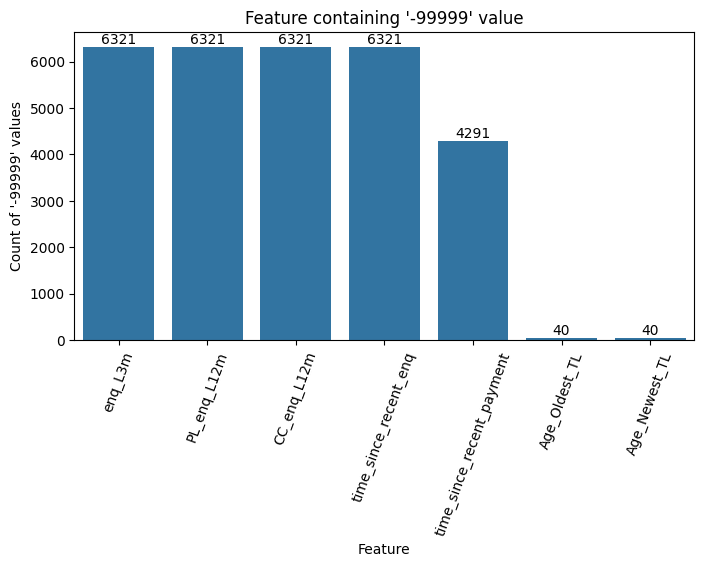

In [29]:
top_problem_col = problem_values[problem_values > 0]

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=top_problem_col.index, y=top_problem_col.values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title("Feature containing '-99999' value")
plt.xlabel("Feature")
plt.xticks(rotation=70)
plt.ylabel("Count of '-99999' values")
plt.show()

So these are the columns with `-99999` values, we'll handle during feature engineering part

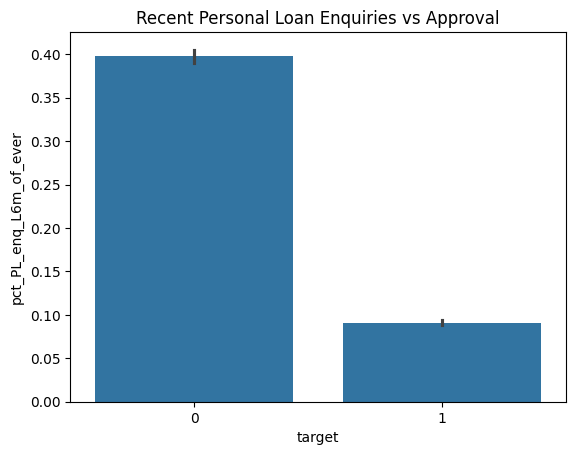

In [40]:
sns.barplot(x='target', y='pct_PL_enq_L6m_of_ever', data=train_df)
plt.title("Recent Personal Loan Enquiries vs Approval")
plt.show()

Applicants with higher number of recent personal loan enquiries have lower approval rate

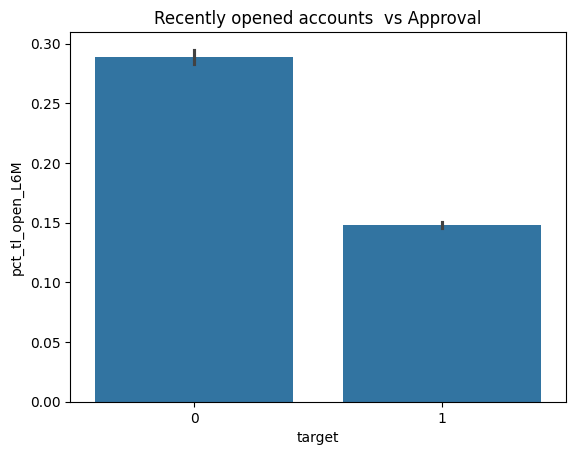

In [48]:
sns.barplot(x='target', y='pct_tl_open_L6M', data=train_df)
plt.title("Recently opened accounts  vs Approval")
plt.show()

Applicants with lesser number of recently opened accounts has higher approval rates

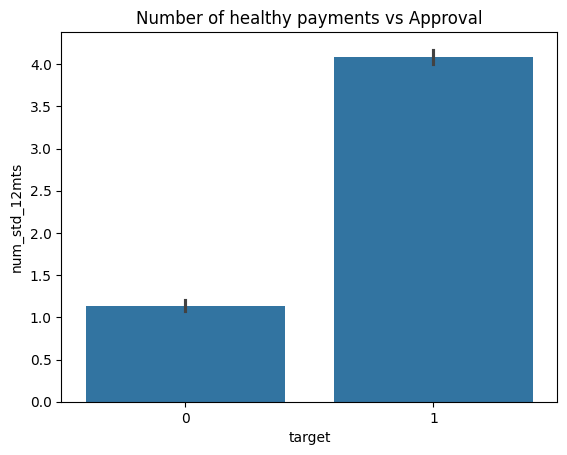

In [49]:
sns.barplot(x='target', y='num_std_12mts', data=train_df)
plt.title("Number of healthy payments vs Approval")
plt.show()

Applicants with higher number of healthy payments in the last 12 months have higher approval rate

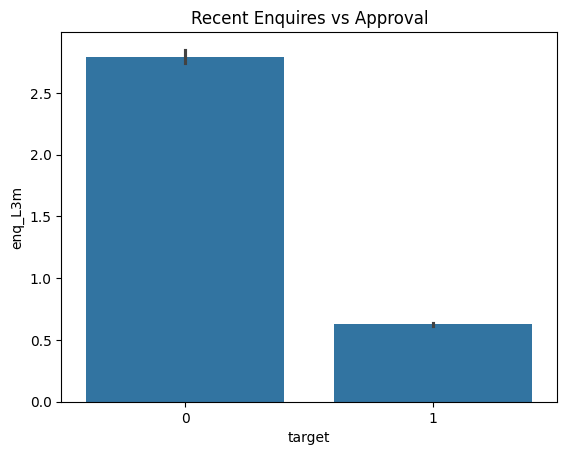

In [42]:
sns.barplot(x='target', y='enq_L3m', data=train_df[train_df['enq_L3m'] != -99999])
plt.title("Recent Enquires vs Approval")
plt.show()

Applicants with higher number of recent enquiries has lower approval rates 

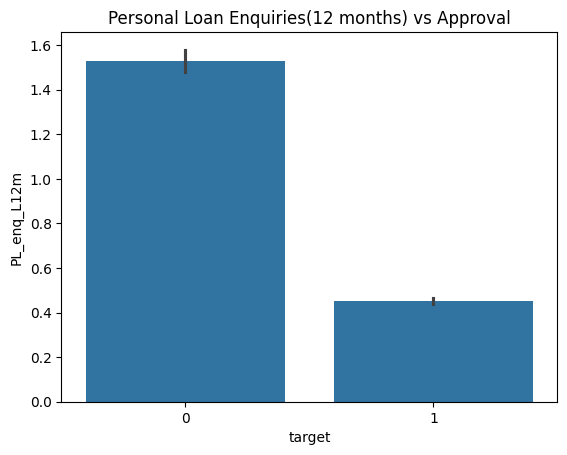

In [50]:
sns.barplot(x='target', y='PL_enq_L12m', data=train_df[train_df['PL_enq_L12m'] != -99999])
plt.title("Personal Loan Enquiries(12 months) vs Approval")
plt.show()

Applicants with lesser number of personal loan enquiries have higher approval rate

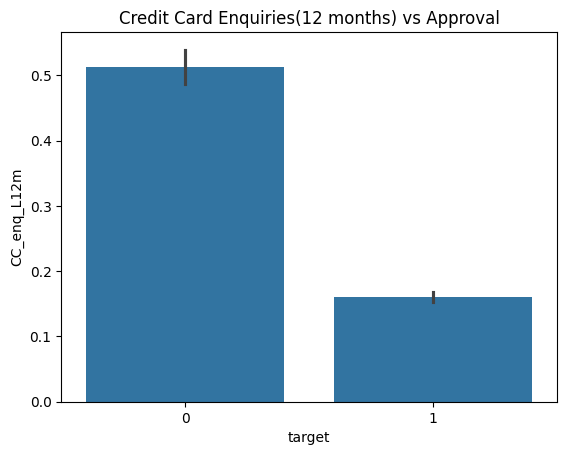

In [53]:
sns.barplot(x='target', y='CC_enq_L12m', data=train_df[train_df['CC_enq_L12m'] != -99999])
plt.title("Credit Card Enquiries(12 months) vs Approval")
plt.show()

Applicants with lesser number of credit card enquiries have higher approval rate

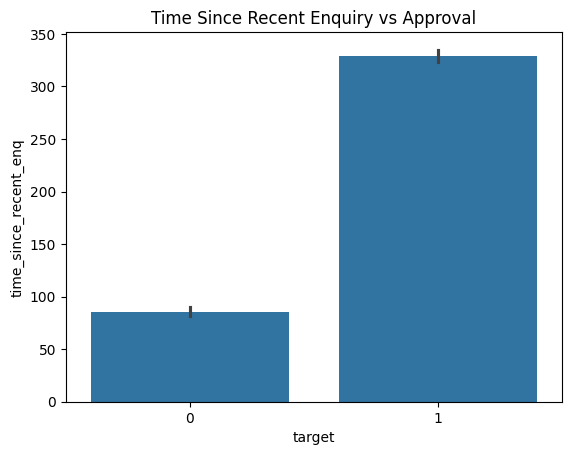

In [55]:
sns.barplot(x='target', y='time_since_recent_enq', data=train_df[train_df['time_since_recent_enq'] != -99999])
plt.title("Time Since Recent Enquiry vs Approval")
plt.show()

Applicants with lesser number of recent enquiries have lesser approval rate

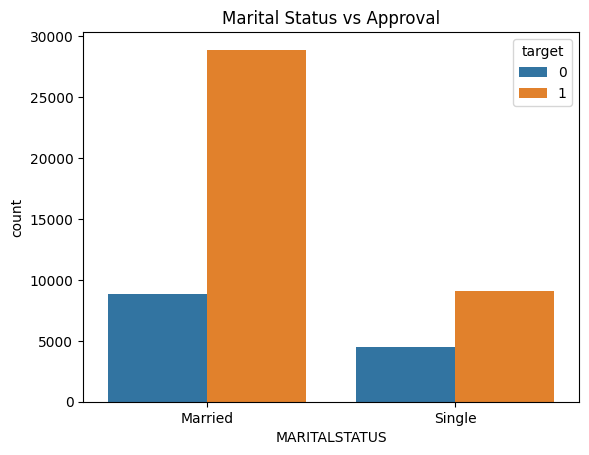

In [58]:
sns.countplot(x=train_df['MARITALSTATUS'], hue=train_df['target'])
plt.title("Marital Status vs Approval")
plt.show()

Married applicants has higher approval rate

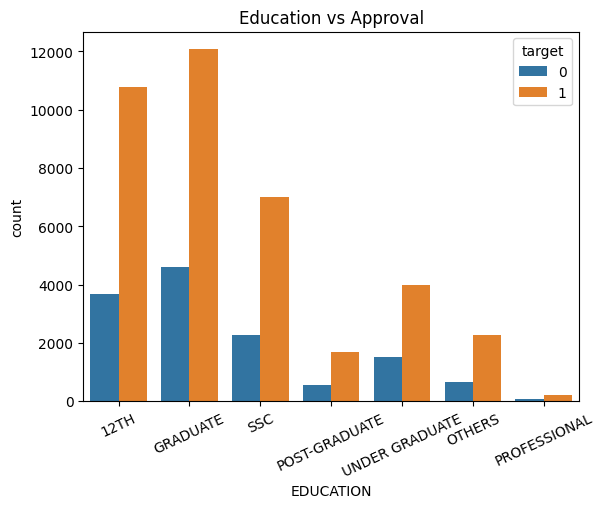

In [60]:
sns.countplot(x=train_df['EDUCATION'], hue=train_df['target'])
plt.title("Education vs Approval")
plt.xticks(rotation=25)
plt.show()

Graduated Applicants has higher overall approval

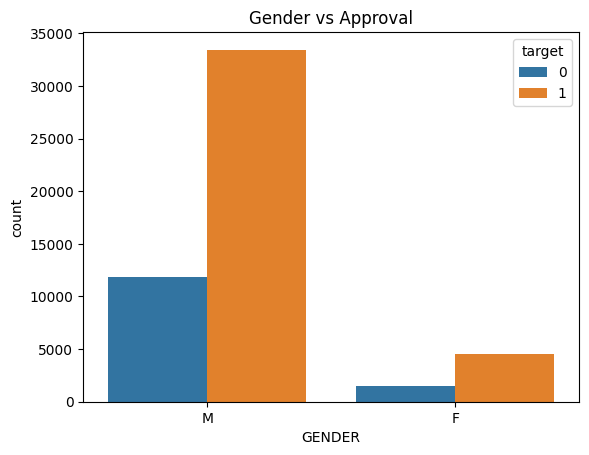

In [61]:
sns.countplot(x=train_df['GENDER'], hue=train_df['target'])
plt.title("Gender vs Approval")
plt.show()

Overall male applicants has higher approval rate

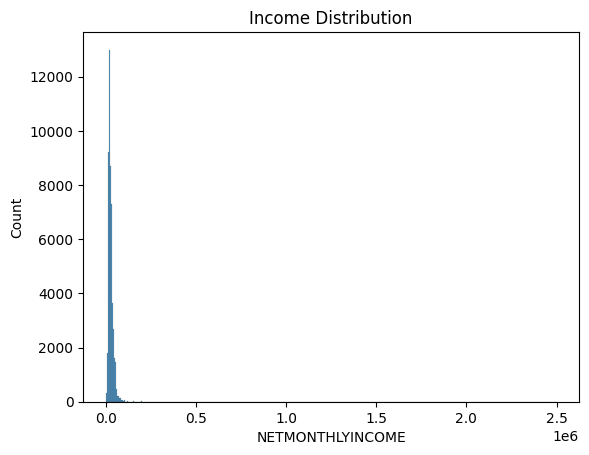

In [63]:
sns.histplot(train_df['NETMONTHLYINCOME'])
plt.title("Income Distribution")
plt.show()

Highly right skewed data, we'll need to transform it.